חלק ראשון של הקוד עם מודל openAi

In [ ]:
# ── Imports ───────────────────────────────────────────────────────────────
!pip install openai
import os
import json
import uuid
import math
import io
import base64
import random
import requests
import numpy as np
import pandas as pd
from PIL import Image, ImageStat, ImageEnhance, ImageFilter
from IPython.display import display
from google.colab import userdata, files

print('Imports loaded')

Imports loaded


In [ ]:
# ── OpenAI API setup ─────────────────────────────────────────────────────
# API key is read from Colab secrets (must be added via the key icon in the sidebar)
API_KEY = userdata.get('OPENAI_API_KEY')
API_URL = "https://api.openai.com/v1/images/generations"

# gpt-image-1 only accepts n=1 per request, so multiple images per combo are
# generated with a loop of separate requests (see generation function below)
MODEL_NAME = "gpt-image-1"
IMAGE_SIZE = "1024x1024"
IMAGE_QUALITY = "low"

HEADERS = {
    "Content-Type": "application/json",
    "Authorization": f"Bearer {API_KEY}"
}

print('OpenAI config ready')

OpenAI config ready


In [ ]:
# ── Define accessibility scenarios and building types ──────────────────────
#
# Each scenario describes a distinct, realistic accessibility configuration.
# Ground-truth (GT) labels are the 3 binary classes used for training:
#   has_ramp              - a wheelchair ramp is present at the entrance
#   has_disabled_parking  - a marked disabled parking spot is visible nearby
#   has_obstacle          - something blocks/narrows the accessible path
#
# Combinations were chosen to be realistic (not all 8 mathematical combos),
# covering the cases that matter most for accessibility detection.

ACCESSIBILITY_SCENARIOS = [
    {
        "name": "stairs_only",
        "label": "Only stairs, no ramp, no disabled parking, no obstacle",
        "prompt": (
            "the entrance is reached only by a set of {stairs_color} concrete stairs, "
            "there is no wheelchair ramp anywhere near the entrance, "
            "no disabled parking spot is visible, "
            "the path and sidewalk leading to the stairs are clear and unobstructed"
        ),
        "labels": {
            "has_ramp": False,
            "has_disabled_parking": False,
            "has_obstacle": False
        }
    },
    {
        "name": "stairs_and_ramp",
        "label": "Stairs and an accessible ramp, no disabled parking, no obstacle",
        "prompt": (
            "the entrance features two separate elements side by side: "
            "first, a wheelchair ramp - a smooth concrete Inclined plane ramp finished in {ramp_color}, about 1.2 "
            "meters wide, rising at a gentle constant incline of roughly 5 degrees from "
            "the sidewalk up to the entrance platform, with metal handrails along both "
            "edges of the ramp, the ramp leads directly to the entrance of the building; "
            "second, completely separate from the ramp with a clearly visible gap of plain "
            "pavement between them, a set of {stairs_color} concrete stairs with no ramp "
            "features on the stairs themselves; "
            "the ramp's {ramp_color} finish is clearly different in color and material "
            "from the {stairs_color} stairs, making the two structures easy to tell apart at a glance; "
            "no disabled parking spot is visible nearby, "
            "the path to the ramp is clear and unobstructed"
        ),
        "labels": {
            "has_ramp": True,
            "has_disabled_parking": False,
            "has_obstacle": False
        }
    },
    {
        "name": "fully_accessible",
        "label": "Ramp and disabled parking present, no obstacle",
        "prompt": (
            "the entrance has a wheelchair ramp: a smooth concrete Inclined plane ramp finished in {ramp_color}, "
            "about 1.2 meters wide, rising at a gentle constant incline of roughly 5 "
            "degrees from the sidewalk up to the entrance platform, with metal handrails "
            "along both edges of the ramp, the ramp leads directly to the entrance of the "
            "building, clearly different in color and material from the rest of the building; "
            "a marked blue disabled parking spot with a wheelchair symbol is visible right next to the building, "
            "the path from the parking spot to the ramp is clear and unobstructed"
        ),
        "labels": {
            "has_ramp": True,
            "has_disabled_parking": True,
            "has_obstacle": False
        }
    },
    {
        "name": "stairs_with_disabled_parking",
        "label": "Only stairs, but a disabled parking spot is present, no obstacle",
        "prompt": (
            "the entrance is reached only by a set of {stairs_color} concrete stairs, there is no wheelchair ramp, "
            "a marked blue disabled parking spot with a wheelchair symbol is visible near the building, "
            "despite the parking spot, a wheelchair user cannot actually reach the door because of the stairs"
        ),
        "labels": {
            "has_ramp": False,
            "has_disabled_parking": True,
            "has_obstacle": False
        }
    },
    {
        "name": "ramp_blocked_by_obstacle",
        "label": "Ramp present but blocked by an obstacle, no disabled parking",
        "prompt": (
            "the entrance has a wheelchair ramp: a smooth concrete Inclined plane ramp finished in {ramp_color}, "
            "about 1.2 meters wide, rising at a gentle constant incline of roughly 5 "
            "degrees from the sidewalk up to the entrance platform, with metal handrails "
            "along both edges, the ramp leads directly to the entrance of the building, "
            "clearly different in color and material from the {stairs_color} stairs "
            "positioned to the side of it with a visible gap of pavement between them, "
            "no disabled parking spot is visible nearby, "
            "however the ramp surface itself is partially blocked by {obstacle}"
        ),
        "labels": {
            "has_ramp": True,
            "has_disabled_parking": False,
            "has_obstacle": True
        }
    },
]

BUILDING_TYPES = [
    {
        "name": "apartment_building",
        "prompt": (
            "a multi-story residential apartment building in an urban area, "
            "plain concrete or plaster facade, "
            "quiet residential street, parked cars and trees along the sidewalk"
        )
    },
    {
        "name": "market",
        "prompt": (
            "a local neighborhood market or grocery store storefront, "
            "large display windows and a storefront sign, "
            "shopping carts and crates near the entrance, busy urban street"
        )
    },
    {
        "name": "mall",
        "prompt": (
            "a large shopping mall entrance, "
            "modern glass facade with automatic sliding doors, "
            "wide plaza in front of the entrance, signage above the doors"
        )
    },
]

# ── Variation pools ──────────────────────────────────────────────────────
#
# These are sampled randomly per generated image (independent of how many
# images are requested), to add visual diversity within the same scenario
# without changing the scenario/building prompt logic itself.

CAMERA_ANGLE_VARIATIONS = [
    "camera tilted downward at a 25 degree angle, viewed from slightly the left",
    "camera tilted downward at a 30 degree angle, viewed straight-on",
    "camera tilted downward at a 35 degree angle, viewed from slightly the right",
    "camera tilted downward at a 40 degree angle, mounted higher up, looking further down",
    "camera tilted downward at a 20 degree angle, mounted lower, closer to eye level",
]

COLOR_VARIATIONS = [
    "the building facade is painted in a warm beige tone",
    "the building facade is a cool light gray tone",
    "the building facade is a reddish brick color",
    "the building facade is painted white with dark window trim",
    "the building facade is a faded pale yellow tone",
    "the building facade is a muted terracotta tone",
]

# Used only by the ramp_blocked_by_obstacle scenario (its prompt has an
# {obstacle} placeholder filled in dynamically - see build_prompt).
OBSTACLE_VARIATIONS = [
    "several trash bins placed directly on the ramp path",
    "a few bicycles parked across the ramp path",
    "stacked construction materials and scaffolding poles left on the ramp",
    "stacked delivery crates and cardboard boxes blocking part of the ramp",
    "a parked motor scooter blocking the middle of the ramp",
    "large potted plants placed on the ramp surface",
    "orange traffic cones and barrier tape strung across the ramp",
    "a folded market stall and shopping cart left on the ramp",
]

# Used wherever a scenario's prompt has a {stairs_color} placeholder.
STAIRS_COLOR_VARIATIONS = [
    "light gray",
    "medium gray",
    "dark charcoal gray",
    "weathered gray",
    "bluish-gray",
    "warm gray",
]

# Used wherever a scenario's prompt has a {ramp_color} placeholder.
# Kept high-contrast vs the gray stairs on purpose (see NOTE above).
RAMP_COLOR_VARIATIONS = [
    "bright safety yellow with black diagonal stripes",
    "bright red with white diagonal stripes",
    "black rubber matting with yellow edge trim",
    "galvanized silver metal with yellow non-slip strips",
    "safety orange with black diagonal stripes",
]

print(f'Defined {len(ACCESSIBILITY_SCENARIOS)} accessibility scenarios')
print(f'Defined {len(BUILDING_TYPES)} building types')
print(f'Defined {len(CAMERA_ANGLE_VARIATIONS)} camera angle variations')
print(f'Defined {len(COLOR_VARIATIONS)} color variations')
print(f'Defined {len(OBSTACLE_VARIATIONS)} obstacle variations')
print(f'Defined {len(STAIRS_COLOR_VARIATIONS)} stairs color variations')
print(f'Defined {len(RAMP_COLOR_VARIATIONS)} ramp color variations')

Defined 5 accessibility scenarios
Defined 3 building types
Defined 5 camera angle variations
Defined 6 color variations
Defined 8 obstacle variations
Defined 6 stairs color variations
Defined 5 ramp color variations


In [ ]:
# ── Helper functions ─────────────────────────────────────────────────────

def make_image_grid(imgs, rows, cols, resize=256):
    """Creates a display grid from a list of images."""
    imgs = [img.resize((resize, resize)) for img in imgs]
    w, h = imgs[0].size
    grid = Image.new('RGB', size=(cols * w, rows * h))
    for i, img in enumerate(imgs):
        grid.paste(img, box=(i % cols * w, i // cols * h))
    return grid


def build_prompt(scenario: dict, building: dict, angle_variation: str = None,
                  color_variation: str = None, obstacle_variation: str = None,
                  stairs_color_variation: str = None, ramp_color_variation: str = None) -> str:

    angle_text = angle_variation or "camera tilted downward at a 30 degree angle, viewed straight-on"
    color_text = color_variation or "the building facade is a neutral gray tone"

    scenario_text = scenario["prompt"].format(
        obstacle=obstacle_variation or "trash bins placed on the ramp",
        stairs_color=stairs_color_variation or "gray",
        ramp_color=ramp_color_variation or "bright yellow",
    )

    prompt = (
        f"CCTV security camera view of a building entrance, "
        f"elevated viewpoint, {angle_text}, "
        f"the entrance is elevated above street level, "
        f"concrete steps lead up from the sidewalk to the front door, "
        f"{building['prompt']}, "
        f"{color_text}, "
        f"{scenario_text}, "
        f"photorealistic, sharp focus, full color, daylight, architectural photography, "
        f"wide establishing shot, full entrance and surrounding sidewalk visible"
    )
    return prompt


def compute_compliance_score(labels: dict) -> int:
    """
    Computes a 0-100 accessibility compliance score from the 3 GT labels.
    This is the target value the model will predict in Phase 2.
    """
    score = 50  # Neutral baseline
    if labels.get("has_ramp", False):
        score += 30
    if labels.get("has_disabled_parking", False):
        score += 25
    if labels.get("has_obstacle", False):
        score -= 35
    return max(0, min(100, score))


def is_frame_suspect(img: Image.Image, mean_brightness_threshold: float = 5.0) -> bool:
    stat = ImageStat.Stat(img.convert("L"))
    return stat.mean[0] < mean_brightness_threshold


def apply_cctv_augmentation(img: Image.Image) -> Image.Image:
    out = img.convert("RGB")

    # 1) Camera-mount rotation (0-15 degrees, random direction) - done first
    #    so the noise/blur/compression steps below also affect the exposed
    #    black corners, instead of leaving them artificially clean
    rotation_angle = random.uniform(0, 15) * random.choice([-1, 1])
    out = out.rotate(rotation_angle, resample=Image.BICUBIC, expand=False, fillcolor=(0, 0, 0))

    # 2) Brightness / contrast jitter
    brightness_factor = random.uniform(0.75, 1.25)
    contrast_factor = random.uniform(0.8, 1.2)
    out = ImageEnhance.Brightness(out).enhance(brightness_factor)
    out = ImageEnhance.Contrast(out).enhance(contrast_factor)

    # 3) Gaussian noise (sensor noise)
    arr = np.array(out).astype(np.float32)
    noise_sigma = random.uniform(3, 12)
    noise = np.random.normal(0, noise_sigma, arr.shape)
    arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
    out = Image.fromarray(arr)

    # 4) Either mild blur OR JPEG compression artifacts (pick one, not both)
    if random.random() < 0.5:
        out = out.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.5, 1.5)))
    else:
        buffer = io.BytesIO()
        out.save(buffer, format="JPEG", quality=random.randint(35, 65))
        buffer.seek(0)
        out = Image.open(buffer).convert("RGB")

    # 5) Grayscale conversion - only some images (~35%), converted back to
    #    3-channel RGB so it stays compatible with the rest of the pipeline
    if random.random() < 0.35:
        out = ImageOps.grayscale(out).convert("RGB")

    return out


def rebuild_metadata_from_disk(out_dir):
    """
    Rebuilds a metadata list by scanning every per-image .json sidecar file
    under out_dir. More robust than reading manifest.json alone: each sidecar
    is written right after its own image is saved, while manifest.json is
    rewritten from scratch on every checkpoint, so a crash/disconnect at the
    exact wrong moment could in theory leave it stale or incomplete.
    Use this after a runtime restart (disk survives, Python variables don't)
    to recover ALL_METADATA before resuming generation.
    """
    records = []
    if not os.path.exists(out_dir):
        return records
    for root, _, files in os.walk(out_dir):
        for fname in files:
            if fname.endswith(".json"):
                with open(os.path.join(root, fname), "r", encoding="utf-8") as f:
                    records.append(json.load(f))
    return records


print('Helper functions loaded')

Helper functions loaded


In [ ]:
# ── Single-image generation call to OpenAI dall-e-3 ─────────────────────────

def generate_one_image_openai(prompt: str, max_retries: int = 3) -> Image.Image:
    """
    Calls the OpenAI images/generations endpoint for a single image.
    Returns a PIL Image. Retries automatically on transient server errors
    (e.g. Cloudflare 5xx errors, which return HTML instead of JSON).
    Raises an exception only after all retries are exhausted.
    """
    payload = {
        "model": MODEL_NAME,
        "prompt": prompt,
        "n": 1,                       # generate one image per request
        "size": IMAGE_SIZE,
        "quality": IMAGE_QUALITY

    }

    last_error = None
    for attempt in range(1, max_retries + 1):
        try:
            response = requests.post(API_URL, headers=HEADERS, json=payload, timeout=120)

            if response.status_code == 200:
                response_data = response.json()
                data_item = response_data['data'][0]

                if 'b64_json' in data_item:
                    image_bytes = base64.b64decode(data_item['b64_json'])
                    return Image.open(io.BytesIO(image_bytes))
                elif 'url' in data_item:
                    img_response = requests.get(data_item['url'])
                    return Image.open(io.BytesIO(img_response.content))
                else:
                    raise RuntimeError(f"Unexpected API response format, keys: {list(data_item.keys())}")

            content_type = response.headers.get("Content-Type", "")
            if "application/json" in content_type:
                error_detail = response.text
            else:
                error_detail = f"non-JSON response (status {response.status_code}), likely a temporary gateway error"

            last_error = RuntimeError(f"OpenAI API error ({response.status_code}): {error_detail}")

            if response.status_code >= 500 and attempt < max_retries:
                wait_time = 5 * attempt  # 5s, 10s, 15s...
                print(f'    transient error (status {response.status_code}), retrying in {wait_time}s '
                      f'(attempt {attempt}/{max_retries})...')
                time.sleep(wait_time)
                continue
            else:
                raise last_error

        except requests.exceptions.RequestException as e:
            last_error = RuntimeError(f"Network error calling OpenAI API: {e}")
            if attempt < max_retries:
                wait_time = 5 * attempt
                print(f'    network error, retrying in {wait_time}s (attempt {attempt}/{max_retries})...')
                time.sleep(wait_time)
                continue
            else:
                raise last_error

    raise last_error


print('generate_one_image_openai ready')

generate_one_image_openai ready


In [ ]:
# ── Generate images for one scenario, varying building/angle/color per image ─

OUT_DIR = "/content/data/accessscan"
MANIFEST_PATH = "/content/data/manifest.json"
ALL_METADATA = []  # Accumulated across the full run


def save_manifest_checkpoint():
    """Writes ALL_METADATA to disk. Called after every single image (not just
    after each scenario), so a crash/disconnect mid-scenario only loses the
    one image being generated at that moment, not the whole scenario."""
    os.makedirs(os.path.dirname(MANIFEST_PATH), exist_ok=True)
    with open(MANIFEST_PATH, "w", encoding="utf-8") as f:
        json.dump(ALL_METADATA, f, ensure_ascii=False, indent=2)


def generate_accessscan_images(scenario: dict, num_images: int = 4):
    """
    Generates num_images images for one scenario using the OpenAI image API.
    For each image, a building type, camera angle, and facade color are
    sampled independently at random from their variation pools - this is
    decoupled from num_images, so changing num_images just changes how many
    times the loop runs, without touching the prompt-building logic at all.
    For ramp_blocked_by_obstacle, an obstacle type is also sampled at random.

    If a returned image looks like a corrupt/black frame (see is_frame_suspect),
    it is regenerated once with the same prompt before giving up and keeping it -
    this does not use an extra API call unless a frame actually looks broken.

    Saves each image + a JSON metadata file alongside it, and checkpoints the
    full manifest to disk after every image. Returns a display grid.
    """
    compliance = compute_compliance_score(scenario["labels"])
    needs_obstacle = "{obstacle}" in scenario["prompt"]

    combo_dir = os.path.join(OUT_DIR, scenario["name"])
    os.makedirs(combo_dir, exist_ok=True)

    images = []
    for i in range(num_images):
        building = random.choice(BUILDING_TYPES)
        angle_variation = random.choice(CAMERA_ANGLE_VARIATIONS)
        color_variation = random.choice(COLOR_VARIATIONS)
        obstacle_variation = random.choice(OBSTACLE_VARIATIONS) if needs_obstacle else None
        stairs_color_variation = random.choice(STAIRS_COLOR_VARIATIONS)
        ramp_color_variation = random.choice(RAMP_COLOR_VARIATIONS) if scenario["labels"]["has_ramp"] else None
        prompt = build_prompt(scenario, building, angle_variation, color_variation, obstacle_variation, stairs_color_variation, ramp_color_variation)

        print(f'  generating image {i + 1}/{num_images}  [{building["name"]}]...')
        img = generate_one_image_openai(prompt)

        if is_frame_suspect(img):
            print('    frame looked corrupt/black, regenerating once...')
            img = generate_one_image_openai(prompt)

        images.append(img)

        img_id = str(uuid.uuid4())[:8]
        filename = f"{scenario['name']}__{building['name']}__{img_id}.png"
        img_path = os.path.join(combo_dir, filename)
        img.save(img_path)

        # Metadata entry - used as the label in Phase 2 training
        meta = {
            "filename": filename,
            "path": img_path,
            "scenario": scenario["name"],
            "scenario_label": scenario["label"],
            "building_type": building["name"],
            "camera_angle_variation": angle_variation,
            "color_variation": color_variation,
            "obstacle_variation": obstacle_variation,
            "stairs_color_variation": stairs_color_variation,
            "ramp_color_variation": ramp_color_variation,
            "prompt": prompt,
            "compliance_score": compliance,
            # Binary GT checklist vector (the 3 accessibility classes)
            "has_ramp": scenario["labels"]["has_ramp"],
            "has_disabled_parking": scenario["labels"]["has_disabled_parking"],
            "has_obstacle": scenario["labels"]["has_obstacle"],
        }
        ALL_METADATA.append(meta)

        json_path = img_path.replace(".png", ".json")
        with open(json_path, "w", encoding="utf-8") as f:
            json.dump(meta, f, ensure_ascii=False, indent=2)

        # Checkpoint after every image - not just after the scenario finishes
        save_manifest_checkpoint()

    cols = min(4, len(images))
    rows = math.ceil(len(images) / cols)
    return make_image_grid(images, rows=rows, cols=cols, resize=256)


print('generate_accessscan_images ready')

generate_accessscan_images ready


Scenario: Ramp and disabled parking present, no obstacle
  generating image 1/1  [market]...


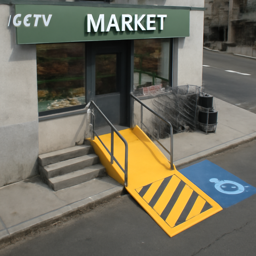

Test passed


In [ ]:
# ── Quick test - single scenario before the full run ────────────────────────

test_scenario = ACCESSIBILITY_SCENARIOS[2]

print(f'Scenario: {test_scenario["label"]}')
test_grid = generate_accessscan_images(test_scenario, num_images=1)
display(test_grid)
print('Test passed')

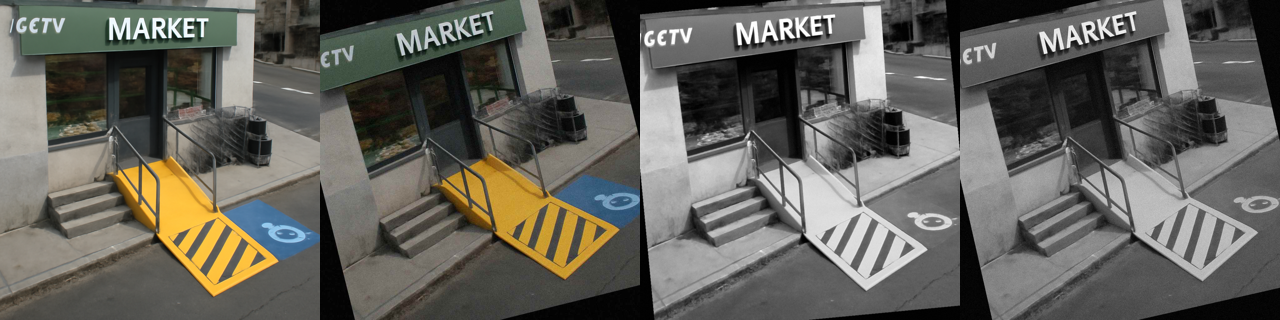

Left to right: original   |   3 augmented samples (CCTV-realism: rotation, brightness/contrast, noise, blur/JPEG, occasional grayscale)


In [ ]:
from PIL import ImageOps

last_meta = ALL_METADATA[-1]
original_img = Image.open(last_meta["path"])
augmented_variants = [apply_cctv_augmentation(original_img) for _ in range(3)]

comparison = make_image_grid([original_img] + augmented_variants, rows=1, cols=4, resize=320)
display(comparison)
print('Left to right: original   |   3 augmented samples (CCTV-realism: rotation, brightness/contrast, noise, blur/JPEG, occasional grayscale)')

In [ ]:
# ── Generate the full dataset ────────────────────────────────────────────
NUM_IMAGES_PER_SCENARIO = 150

if not ALL_METADATA:
    ALL_METADATA = rebuild_metadata_from_disk(OUT_DIR)
    if ALL_METADATA:
        print(f'Recovered {len(ALL_METADATA)} existing images by scanning disk')
    else:
        print('No existing data found on disk - starting fresh')

print('Starting AccessScan dataset generation (OpenAI gpt-image-1)')
print(f'   Scenarios: {len(ACCESSIBILITY_SCENARIOS)}')
print(f'   Target images per scenario: {NUM_IMAGES_PER_SCENARIO}')
print('=' * 50)

for scenario in ACCESSIBILITY_SCENARIOS:
    existing_count = sum(
        1 for m in ALL_METADATA
        if m["scenario"] == scenario["name"] and not m.get("is_augmented", False)
    )
    remaining = NUM_IMAGES_PER_SCENARIO - existing_count

    if remaining <= 0:
        print(f'\n>> {scenario["label"]}  -  already has {existing_count}/{NUM_IMAGES_PER_SCENARIO}, skipping')
        continue

    print(f'\n>> {scenario["label"]}  -  {existing_count}/{NUM_IMAGES_PER_SCENARIO} existing, generating {remaining} more')
    grid = generate_accessscan_images(scenario, num_images=remaining)
    display(grid)

print('\n' + '=' * 50)
print(f'Generated {len(ALL_METADATA)} images total')
print(f'   Saved to: {OUT_DIR}')

Starting AccessScan dataset generation (OpenAI gpt-image-1)
   Scenarios: 5
   Target images per scenario: 150

>> Only stairs, no ramp, no disabled parking, no obstacle  -  0/150 existing, generating 150 more
  generating image 1/150  [apartment_building]...
  generating image 2/150  [mall]...
  generating image 3/150  [market]...


KeyboardInterrupt: 

In [ ]:
# ── Data augmentation - simulate real CCTV image quality ──────────────────

AUGMENTATION_FRACTION = 0.5  # portion of images that get one augmented copy

print('Starting CCTV-realism augmentation pass...')
original_metadata = list(ALL_METADATA)  # snapshot before adding augmented entries
num_to_augment = int(len(original_metadata) * AUGMENTATION_FRACTION)
chosen = random.sample(original_metadata, num_to_augment)

for meta in chosen:
    orig_path = meta["path"]
    img = Image.open(orig_path)
    aug_img = apply_cctv_augmentation(img)

    aug_filename = meta["filename"].replace(".png", "__aug.png")
    aug_path = os.path.join(os.path.dirname(orig_path), aug_filename)
    aug_img.save(aug_path)

    aug_meta = dict(meta)
    aug_meta["filename"] = aug_filename
    aug_meta["path"] = aug_path
    aug_meta["is_augmented"] = True
    aug_meta["source_image"] = meta["filename"]
    ALL_METADATA.append(aug_meta)

    aug_json_path = aug_path.replace(".png", ".json")
    with open(aug_json_path, "w", encoding="utf-8") as f:
        json.dump(aug_meta, f, ensure_ascii=False, indent=2)

# Mark originals explicitly too (so is_augmented always exists in the manifest)
for meta in ALL_METADATA:
    if "is_augmented" not in meta:
        meta["is_augmented"] = False

save_manifest_checkpoint()
print(f'Added {num_to_augment} augmented images ({AUGMENTATION_FRACTION:.0%} of originals)')
print(f'Total images now: {len(ALL_METADATA)}')

Starting CCTV-realism augmentation pass...


KeyboardInterrupt: 

In [ ]:
# ── Statistics and summary ───────────────────────────────────────────────
df = pd.DataFrame(ALL_METADATA)

print('Compliance score distribution:')
print(df['compliance_score'].describe().round(1))

print('\nImages per scenario:')
print(df['scenario'].value_counts())

print('\nImages per building type:')
print(df['building_type'].value_counts())

print('\nLabel feature counts (how many images have each feature):')
for col in ['has_ramp', 'has_disabled_parking', 'has_obstacle']:
    print(f'  {col}: {df[col].sum()} / {len(df)}')

df.to_csv("/content/data/dataset.csv", index=False)
print('\nSaved: /content/data/dataset.csv')

Compliance score distribution:
count    327.0
mean      52.7
std       13.3
min       45.0
25%       45.0
50%       45.0
75%       75.0
max      100.0
Name: compliance_score, dtype: float64

Images per scenario:
scenario
ramp_blocked_by_obstacle        244
stairs_with_disabled_parking     82
fully_accessible                  1
Name: count, dtype: int64

Images per building type:
building_type
market                144
apartment_building     93
mall                   90
Name: count, dtype: int64

Label feature counts (how many images have each feature):
  has_ramp: 245 / 327
  has_disabled_parking: 83 / 327
  has_obstacle: 244 / 327

Saved: /content/data/dataset.csv


In [ ]:
# ── Download dataset as zip ──────────────────────────────────────────────
import shutil

zip_path = "/content/accessscan_dataset"
shutil.make_archive(zip_path, 'zip', "/content/data")
print(f'Created: {zip_path}.zip')

files.download(f"{zip_path}.zip")
print('Download starting...')

Created: /content/accessscan_dataset.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download starting...


# Generate, Augmentation and ZIP seperated by the scenarios:

In [ ]:
# ── Generate 100 images - scenario  only  ──────────────

scenario_4 = ACCESSIBILITY_SCENARIOS[3]
NUM_IMAGES_SCENARIO_4 = 100

if not ALL_METADATA:
    ALL_METADATA = rebuild_metadata_from_disk(OUT_DIR)
    if ALL_METADATA:
        print(f'Recovered {len(ALL_METADATA)} existing images by scanning disk')

existing_count = sum(
    1 for m in ALL_METADATA
    if m["scenario"] == scenario_4["name"] and not m.get("is_augmented", False)
)
remaining = NUM_IMAGES_SCENARIO_4 - existing_count

if remaining <= 0:
    print(f'{scenario_4["label"]}  -  already has {existing_count}/{NUM_IMAGES_SCENARIO_4}, nothing to do')
else:
    print(f'{scenario_4["label"]}  -  {existing_count}/{NUM_IMAGES_SCENARIO_4} existing, generating {remaining} more')
    scenario_4_grid = generate_accessscan_images(scenario_4, num_images=remaining)
    display(scenario_4_grid)

Only stairs, but a disabled parking spot is present, no obstacle  -  0/100 existing, generating 100 more
  generating image 1/100  [apartment_building]...
  generating image 2/100  [apartment_building]...
  generating image 3/100  [market]...
  generating image 4/100  [market]...
  generating image 5/100  [market]...
  generating image 6/100  [market]...
  generating image 7/100  [apartment_building]...
  generating image 8/100  [mall]...
  generating image 9/100  [mall]...
  generating image 10/100  [market]...
  generating image 11/100  [mall]...
  generating image 12/100  [apartment_building]...
  generating image 13/100  [mall]...
  generating image 14/100  [mall]...
  generating image 15/100  [mall]...
  generating image 16/100  [apartment_building]...
  generating image 17/100  [mall]...
  generating image 18/100  [market]...
  generating image 19/100  [market]...
  generating image 20/100  [mall]...
  generating image 21/100  [market]...
  generating image 22/100  [apartment_bui

RuntimeError: OpenAI API error (400): {
  "error": {
    "message": "Billing hard limit has been reached.",
    "type": "billing_limit_user_error",
    "param": null,
    "code": "billing_hard_limit_reached"
  }
}

In [ ]:
# ── Data augmentation - simulate real CCTV image quality (scenario 5 only) ─

AUGMENTATION_FRACTION = 0.5  # portion of images that get one augmented copy
SCENARIO_TO_AUGMENT = "stairs_with_disabled_parking"

print(f'Starting CCTV-realism augmentation pass (scenario: {SCENARIO_TO_AUGMENT})...')
original_metadata = [
    m for m in ALL_METADATA
    if m["scenario"] == SCENARIO_TO_AUGMENT and not m.get("is_augmented", False)
]
num_to_augment = int(len(original_metadata) * AUGMENTATION_FRACTION)
chosen = random.sample(original_metadata, num_to_augment)

for meta in chosen:
    orig_path = meta["path"]
    img = Image.open(orig_path)
    aug_img = apply_cctv_augmentation(img)

    aug_filename = meta["filename"].replace(".png", "__aug.png")
    aug_path = os.path.join(os.path.dirname(orig_path), aug_filename)
    aug_img.save(aug_path)

    aug_meta = dict(meta)
    aug_meta["filename"] = aug_filename
    aug_meta["path"] = aug_path
    aug_meta["is_augmented"] = True
    aug_meta["source_image"] = meta["filename"]
    ALL_METADATA.append(aug_meta)

    aug_json_path = aug_path.replace(".png", ".json")
    with open(aug_json_path, "w", encoding="utf-8") as f:
        json.dump(aug_meta, f, ensure_ascii=False, indent=2)

# Mark originals explicitly too (so is_augmented always exists in the manifest)
for meta in ALL_METADATA:
    if "is_augmented" not in meta:
        meta["is_augmented"] = False

save_manifest_checkpoint()
print(f'Added {num_to_augment} augmented images ({AUGMENTATION_FRACTION:.0%} of {SCENARIO_TO_AUGMENT} originals)')
print(f'Total images now: {len(ALL_METADATA)}')

Starting CCTV-realism augmentation pass (scenario: stairs_with_disabled_parking)...
Added 41 augmented images (50% of stairs_with_disabled_parking originals)
Total images now: 575


In [ ]:

# ── Download scenario 4 folder as zip (fully_accessible) ────────────────
import shutil

scenario_3_name = ACCESSIBILITY_SCENARIOS[0]["name"]
scenario_3_dir = os.path.join(OUT_DIR, scenario_3_name)

zip_path = f"/content/{scenario_3_name}"
shutil.make_archive(zip_path, 'zip', scenario_3_dir)
print(f'Created: {zip_path}.zip  (only the {scenario_3_name} folder)')

files.download(f"{zip_path}.zip")
print('Download starting...')